# Demo 2 Cantielver's Response to Hard Pulses

We want to use our simulator to simulate cantilever's responese to a hard pulse.

In [1]:
import sys
from pathlib import Path
repo_root = Path.cwd().parent   # demo/data → demo → browniansim/
sys.path.insert(0, str(repo_root))
import browniansim as bs

import numpy as np
import matplotlib.pyplot as plt

# Hard Pulse


In this simulator, time is normalized and denoted as $\tau$, where $\tau = w_0 t$. That is to say, $\tau$ is a dimensionless parameter defined by multiplying the physical time $t$ with the resonant angular frequency $w_0$ of the system. Therefore, the equation to be solved is:

$\frac{d^2x}{d\tau^2}+\frac{1}{Q}\frac{dx}{d\tau}+x = \frac{F(\tau)}{mw_0^2}$

$F(\tau) = F_0\theta(\tau)\theta(\tau_0-\tau)$,$x(0)=0,p(0)=0$


## t<t0

$\frac{d^2x}{d\tau^2}+\frac{1}{Q}\frac{dx}{d\tau}+x = \frac{F_0}{mw_0^2}$
$\frac{d^2x}{d\tau^2}+\frac{1}{Q}\frac{dx}{d\tau}+(x-\frac{F_0}{mw_0^2}) = 0$
$\frac{d^2x_1}{d\tau^2}+\frac{1}{Q}\frac{dx_1}{d\tau}+x_1 = 0$
it is a ring down, $x1(0) = -\frac{F_0}{mw_0^2}$; $p1(0) =0$,
 so $x(t) = x_1(t)+\frac{F_0}{mw_0^2} =\frac{F_0}{mw_0^2}[1-\exp(-\tau / Q / 2) * \cos( \tau*\sqrt{(-1 / Q^2 / 4 + 1)}) ] = \frac{F_0}{mw_0^2}[1-\exp(-w_0*t/Q/2) * \cos( w_0*\sqrt{(-1 / Q^2 / 4 + 1)}*t) ]$, 
as Q>>1, $x(t) = \frac{F_0}{mw_0^2}[1-\exp(-w_0*t/Q/2) * \cos( w_0*t) ]$, then $\frac{dx}{d\tau} = \frac{F_0}{mw_0^2}[\frac{1}{2Q}\exp(-\tau / Q / 2)\cos( \tau )+\exp(-\tau / Q / 2)\sin(\tau)]\approx \frac{F_0}{mw_0^2}\exp(-\tau / Q / 2)\sin(\tau)$

 $x(\tau_0) = \frac{F_0}{mw_0^2}[1-\exp(-\tau_0/Q/2) * \cos( \tau_0) ], p(\tau_0) =  \frac{F_0}{mw_0^2}\exp(-\tau_0 / Q / 2)\sin(\tau_0)$

 ## t>t0
 It is still a ring down, with $[x(t_0),p(t_0)] = [\frac{F_0}{mw_0^2}[1-\exp(-\tau_0/Q/2) * \cos( \tau_0) ],\frac{F_0}{mw_0^2}\exp(-\tau_0 / Q / 2)\sin(\tau_0)]$; then $x(t) =  \frac{F_0}{mw_0^2}[(1-\exp(-\tau_0/Q/2)) * \cos( \tau_0)*\exp(-(\tau-\tau_0)/Q/2) * \cos(\tau- \tau_0)+\exp(-\tau_0 / Q / 2)\sin(\tau_0)*\exp(-(\tau-\tau_0) / Q / 2)\sin(\tau-\tau_0)]$

# Generating hard pulse

In [2]:
def hard_pulse(tau_l,tau_0,F_0):
    '''
    Generate a hard pulse with a duration of tau_0 and a force of F_0 (F/m/w_0^2).
    '''
    F = np.zeros_like(tau_l)
    F[tau_l<tau_0] = F_0
    F[tau_l>=tau_0] = 0
    return np.tile(F[:, np.newaxis], (1, 4))

def hard_pulse_simulator(tau_0,F_0,dtau,dw_l,Q,X0_0=[0,0]):
    F = hard_pulse(tau_l,tau_0,F_0)
    sig_simulation_RK4 = bs.solve_RK4(X0_0, dtau, Q, F,dw_l)

    return sig_simulation_RK4,F

def hard_pulse_response_analytical(tau_0,F_0,tau_l,Q,X0_0=[0,0]):
    x = np.zeros_like(tau_l)

    x[tau_l<tau_0] = F_0*(1-np.exp(-tau_l[tau_l<tau_0]/Q/2)*np.cos(tau_l[tau_l<tau_0]))

    x[tau_l>=tau_0] = F_0*((1-np.exp(-tau_0/Q/2)*np.cos(tau_0))*np.exp(-(tau_l[tau_l>=tau_0]-tau_0)/Q/2)*np.cos(tau_l[tau_l>=tau_0]-tau_0)+np.exp(-tau_0/Q/2)*np.sin(tau_0)*np.exp(-(tau_l[tau_l>=tau_0]-tau_0)/Q/2)*np.sin(tau_l[tau_l>=tau_0]-tau_0))

    return x






--------------------------------
F_0= 1


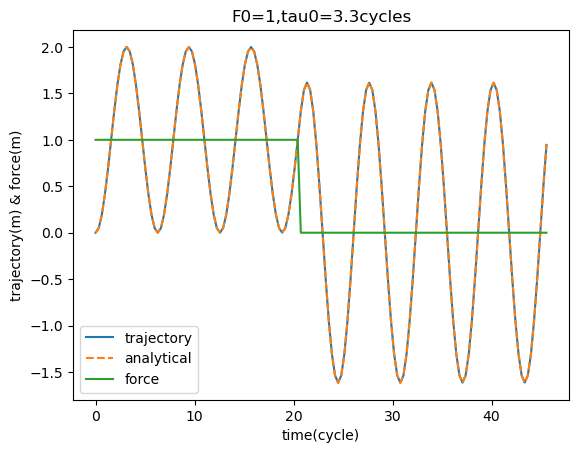

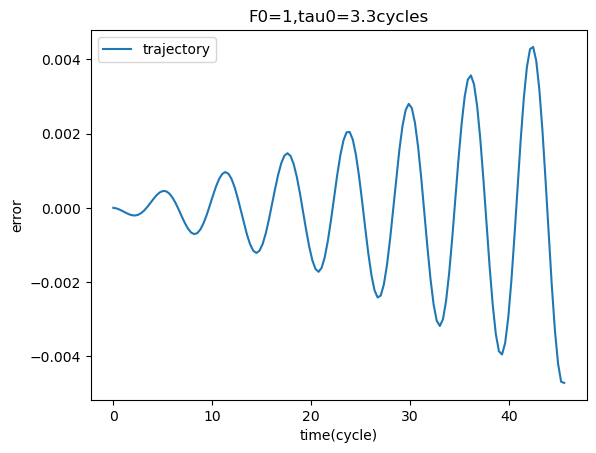

--------------------------------
F_0= 2


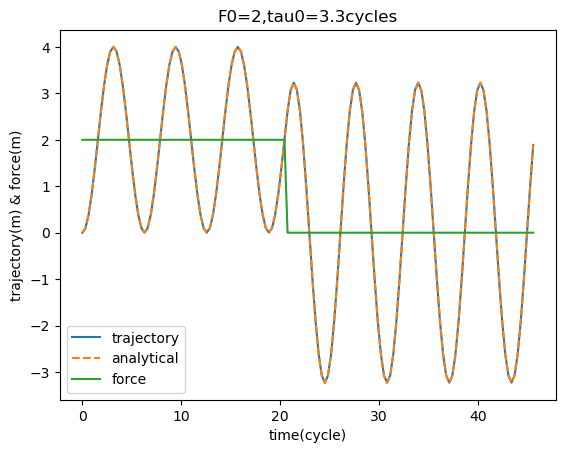

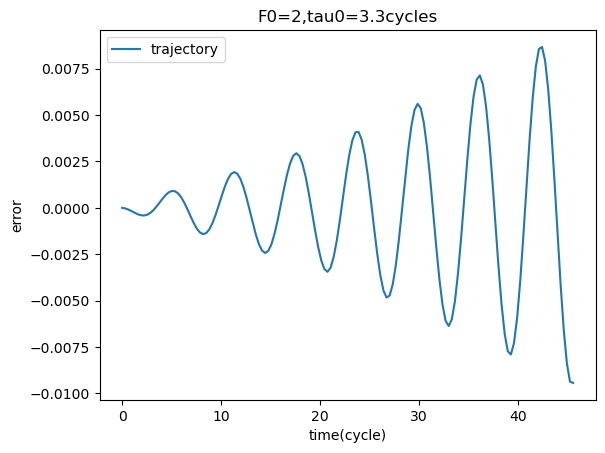

--------------------------------
F_0= 5


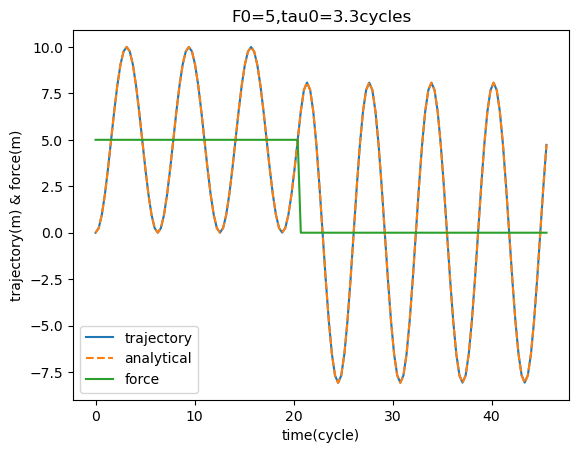

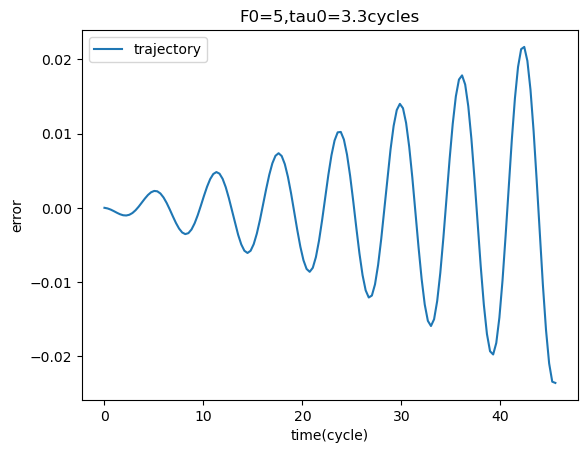

--------------------------------
F_0= 10


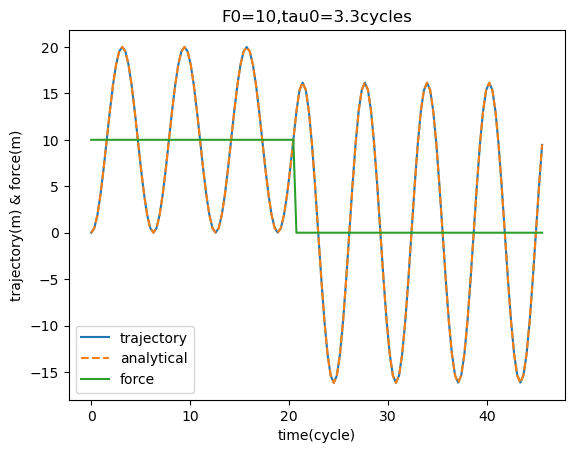

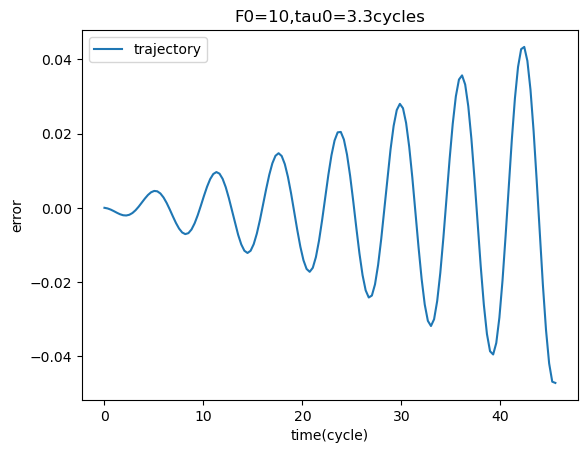

In [4]:
dtau = 0.05*2*np.pi #our sampling rate is about 200kHz, w0 is about 8k, so about 20 times bigger
dw = np.array([]) # we need to set the efficient rad freq for eacxh set, w_eff = 1+dw, and real rad freq w(t) = w0*w_eff = w0*(1+dw)
n = 7.3 # number of cycles in each pulse
dw_l = np.zeros((int(n*2*np.pi/dtau),4))#w = 1+dw
tau_l = np.arange(0,len(dw_l)*dtau,dtau)
X0_0 = [0,0]# initial displacement and velocity for simulation
Q=10000
tau_0 = 3.3*np.pi*2#the duration of the pulse
F_0 = 10#the force of the pulse
F_0_l = [1,2,5,10]
for F_0 in F_0_l:
    print('--------------------------------')
    print('F_0=',F_0)
    sig_simulation_RK4,F = hard_pulse_simulator(tau_0,F_0,dtau,dw_l,Q,X0_0)
    analytical_x = hard_pulse_response_analytical(tau_0,F_0,tau_l,Q,X0_0)
    plt.plot(tau_l, sig_simulation_RK4[:,0], label='trajectory')
    plt.plot(tau_l, analytical_x, label='analytical', linestyle='--')  
    plt.plot(tau_l, F[:,0], label='force')
    plt.title('F0='+str(F_0)+',tau0='+str(tau_0/np.pi/2)+'cycles')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m) & force(m)')
    plt.legend()
    plt.show()

    plt.plot(tau_l, sig_simulation_RK4[:,0]-analytical_x, label='trajectory')
    plt.title('F0='+str(F_0)+',tau0='+str(tau_0/np.pi/2)+'cycles')
    plt.xlabel('time(cycle)')
    plt.ylabel('error')
    plt.legend()
    plt.show()




--------------------------------
tau_0= 0.6283185307179586


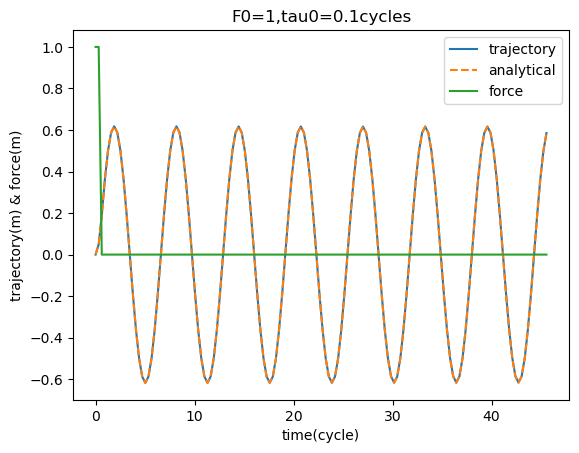

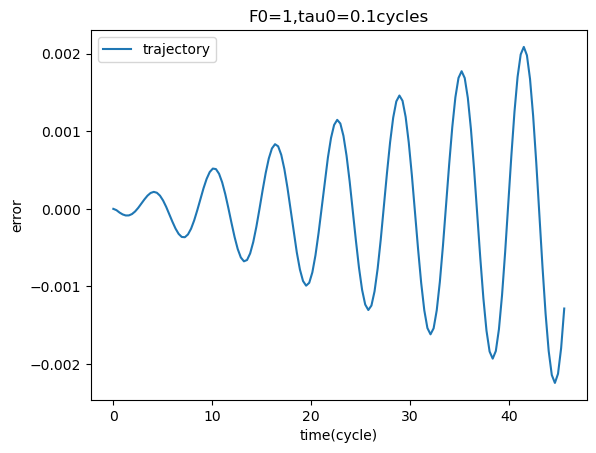

--------------------------------
tau_0= 1.8849555921538759


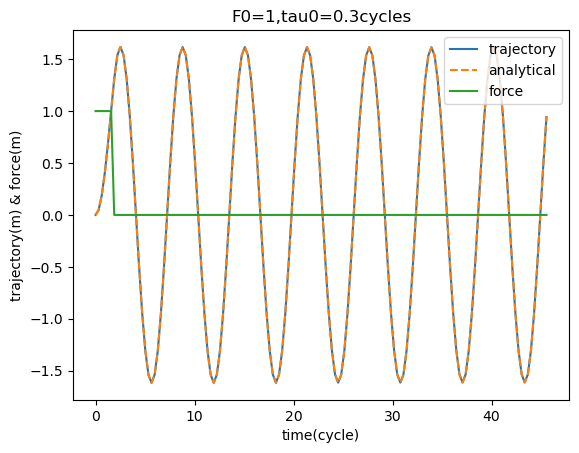

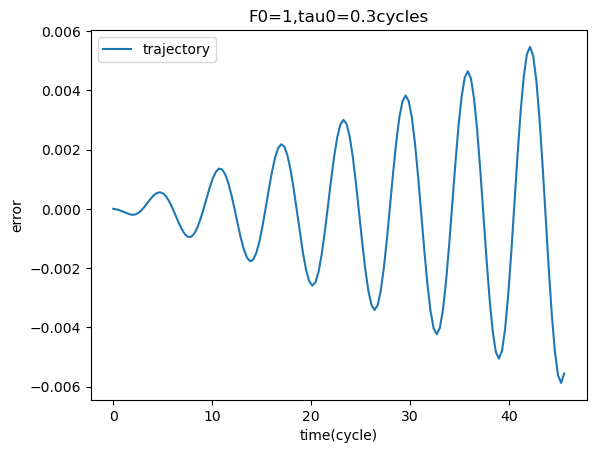

--------------------------------
tau_0= 3.7699111843077517


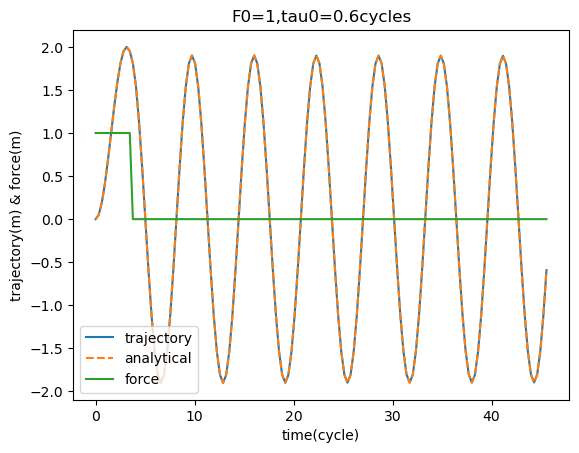

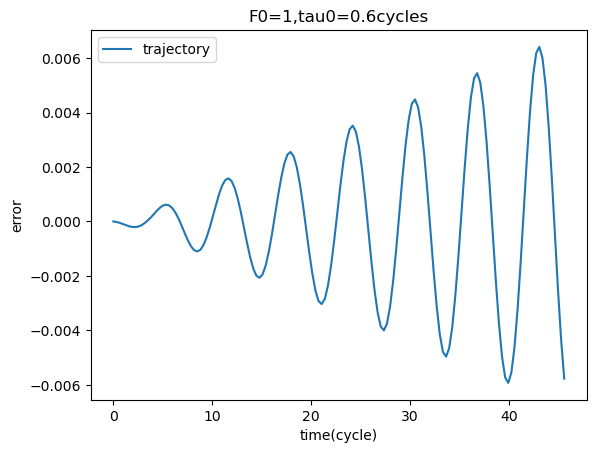

--------------------------------
tau_0= 5.654866776461628


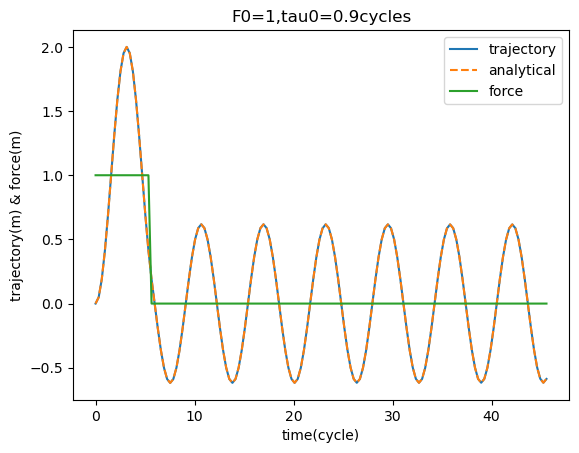

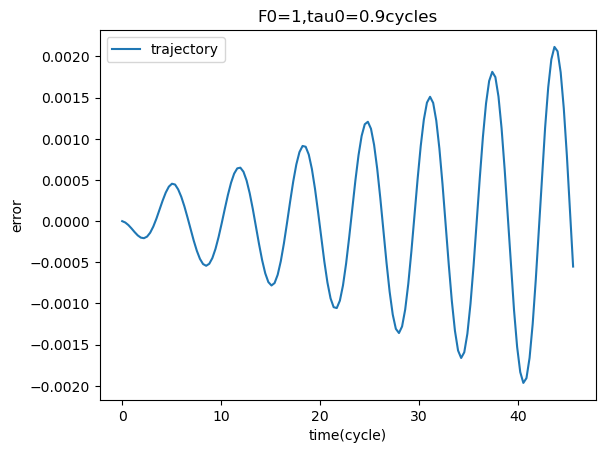

--------------------------------
tau_0= 19.477874452256717


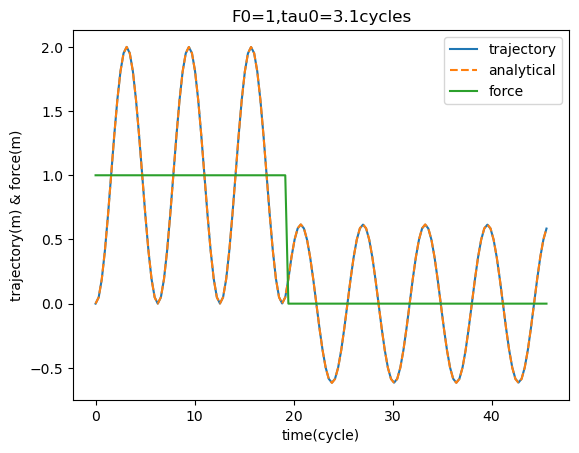

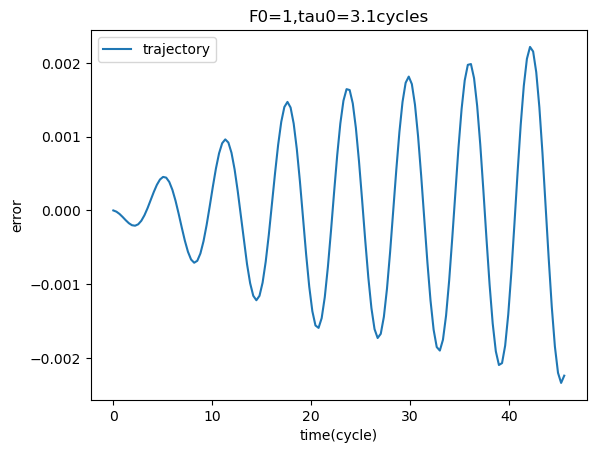

In [5]:
F_0 = 1
tau_0_l = [0.1*2*np.pi,0.3*2*np.pi,0.6*2*np.pi,0.9*2*np.pi,3.1*2*np.pi]
for tau_0 in tau_0_l:
    print('--------------------------------')
    print('tau_0=',tau_0)
    sig_simulation_RK4,F = hard_pulse_simulator(tau_0,F_0,dtau,dw_l,Q,X0_0)
    analytical_x = hard_pulse_response_analytical(tau_0,F_0,tau_l,Q,X0_0)
    plt.plot(tau_l, sig_simulation_RK4[:,0], label='trajectory')
    plt.plot(tau_l, analytical_x, label='analytical', linestyle='--')  
    plt.plot(tau_l, F[:,0], label='force')
    plt.title('F0='+str(F_0)+',tau0='+str(tau_0/np.pi/2)+'cycles')
    plt.xlabel('time(cycle)')
    plt.ylabel('trajectory(m) & force(m)')
    plt.legend()
    plt.show()

    plt.plot(tau_l, sig_simulation_RK4[:,0]-analytical_x, label='trajectory')
    plt.title('F0='+str(F_0)+',tau0='+str(tau_0/np.pi/2)+'cycles')
    plt.xlabel('time(cycle)')
    plt.ylabel('error')
    plt.legend()
    plt.show()

The error is acceptable, it seems that the error is increasing, this is due to our simulator slightly underestimate our Q